# 05 - Evaluacion final, matriz de confusion y speedup

Este notebook interpreta los resultados finales del proyecto. Aqui se revisa el conjunto `test`, la matriz de confusion y las comparaciones de rendimiento paralelo.

El conjunto `test` debe usarse solo al final, porque representa imagenes que el modelo no debe haber usado para aprender ni para seleccionar pesos.


## Bloque 1: preparar rutas y utilidades

Este bloque ubica la carpeta de metricas y prepara funciones para mostrar Markdown e imagenes. No modifica archivos ni entrena el modelo.


In [1]:
from pathlib import Path
import json
import sys

from IPython.display import Image, Markdown, display

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

METRICS = ROOT / "metrics"
METRICS


PosixPath('/mnt/c/Users/USUARIO/Documents/PARALELAS/yawn-detection-mlp/metrics')

## Bloque 2: mostrar metricas finales

Este bloque muestra accuracy, precision, recall y F1-score desde `metrics/results.md`. Estas metricas se calculan sobre `test`, no sobre entrenamiento.


In [2]:
results_report = METRICS / "results.md"
if results_report.exists():
    display(Markdown(results_report.read_text(encoding="utf-8")))
else:
    print("No existe results.md. Se genera despues de ejecutar manualmente: python -m src.train")


# Resultados de evaluacion

| Metrica | Valor |
|---|---:|
| Accuracy | 0.8229 |
| Precision | 0.8444 |
| Recall | 0.7917 |
| F1 Score | 0.8172 |


## Bloque 3: mostrar matriz de confusion

La matriz de confusion permite ver aciertos y errores por clase. En este proyecto interesa especialmente distinguir falsos positivos de bostezo y falsos negativos de bostezo.


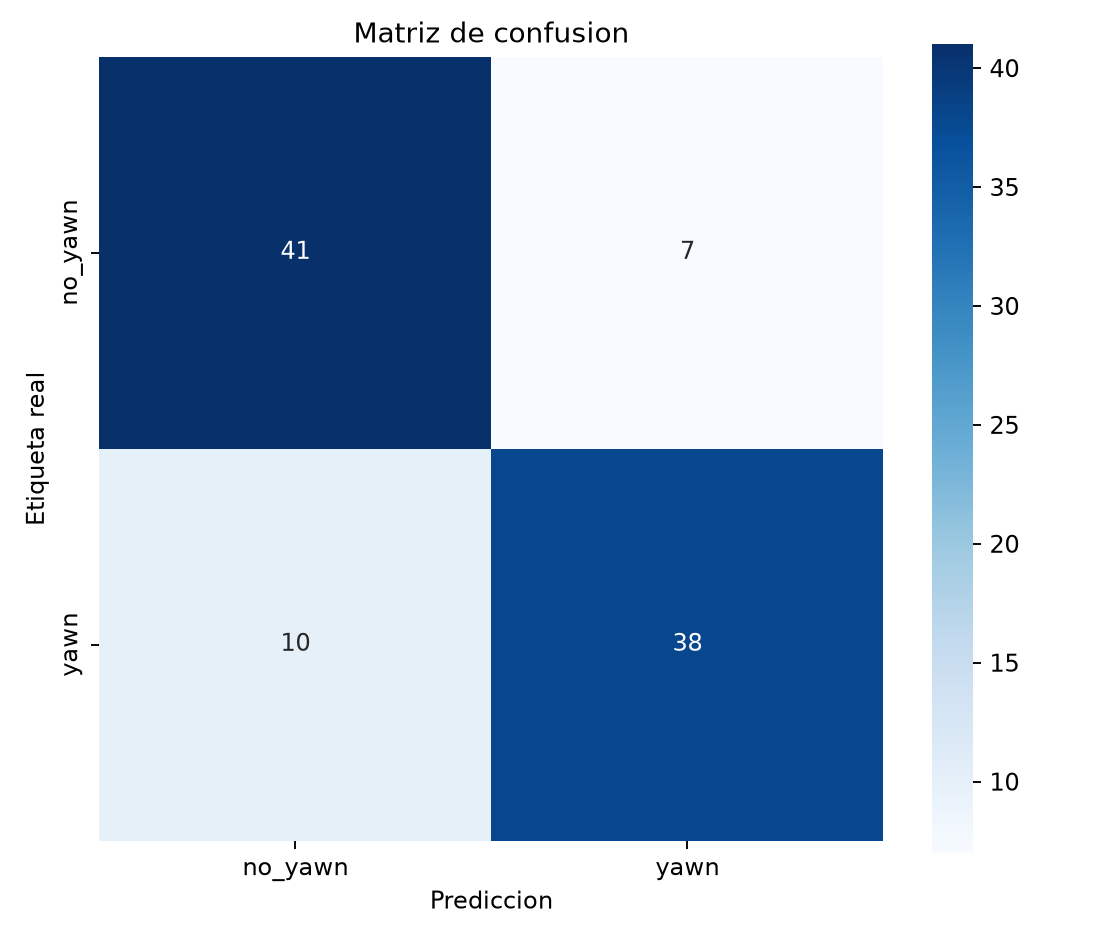

In [3]:
confusion = METRICS / "confusion_matrix.png"
if confusion.exists():
    display(Image(filename=str(confusion)))
else:
    print("No existe confusion_matrix.png.")


## Bloque 4: interpretar errores de clasificacion

Este bloque explica como leer la matriz. No necesita acceso a imagenes individuales; sirve para preparar la exposicion oral.


In [4]:
print("Interpretacion de la matriz:")
print("- Fila no_yawn, columna no_yawn: no bostezos clasificados correctamente.")
print("- Fila no_yawn, columna yawn: falsos positivos, el modelo dijo bostezo cuando no lo era.")
print("- Fila yawn, columna no_yawn: falsos negativos, el modelo no detecto un bostezo real.")
print("- Fila yawn, columna yawn: bostezos clasificados correctamente.")


Interpretacion de la matriz:
- Fila no_yawn, columna no_yawn: no bostezos clasificados correctamente.
- Fila no_yawn, columna yawn: falsos positivos, el modelo dijo bostezo cuando no lo era.
- Fila yawn, columna no_yawn: falsos negativos, el modelo no detecto un bostezo real.
- Fila yawn, columna yawn: bostezos clasificados correctamente.


## Bloque 5: mostrar speedup de OpenMP y CUDA

OpenMP mide el tiempo de preprocesamiento serial contra paralelo. CUDA mide el tiempo del entrenamiento CPU contra entrenamiento GPU. Ambas graficas comparan tiempo total medido en milisegundos.


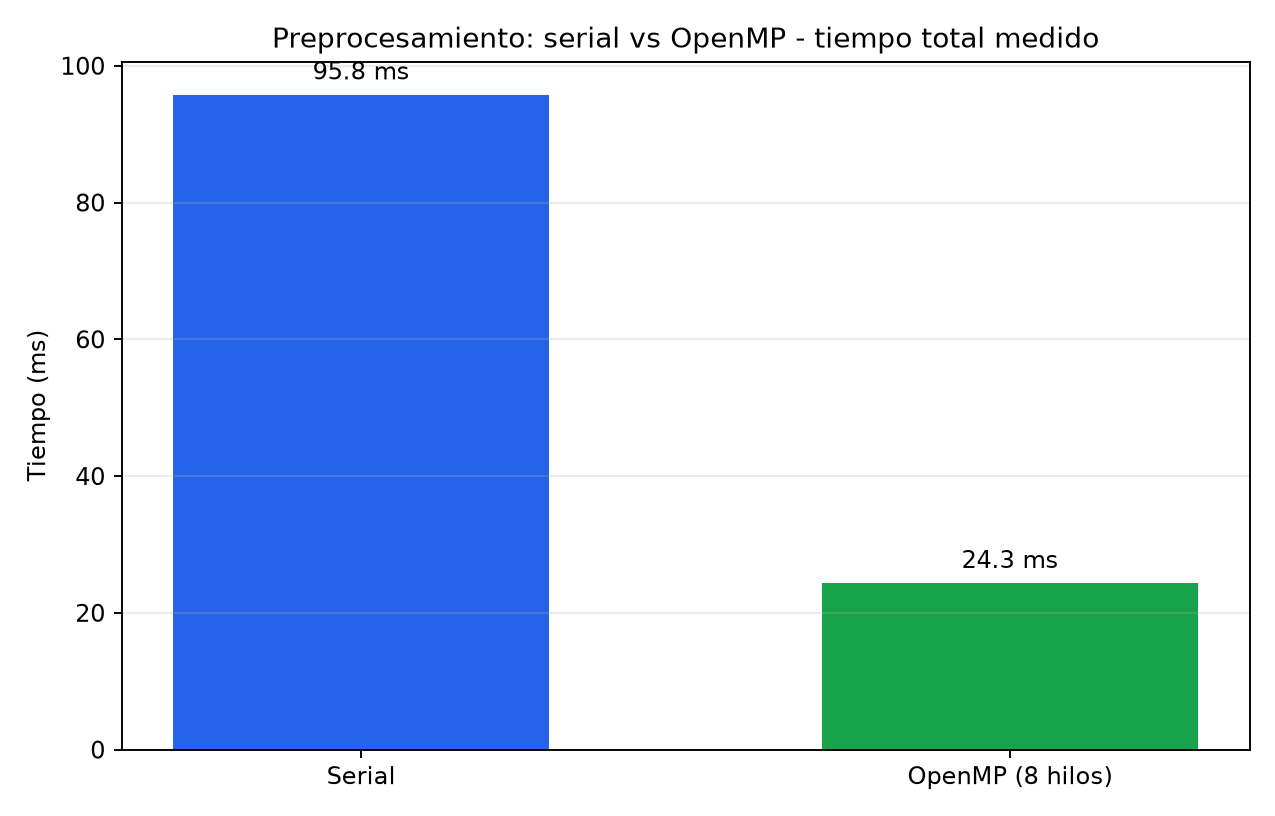

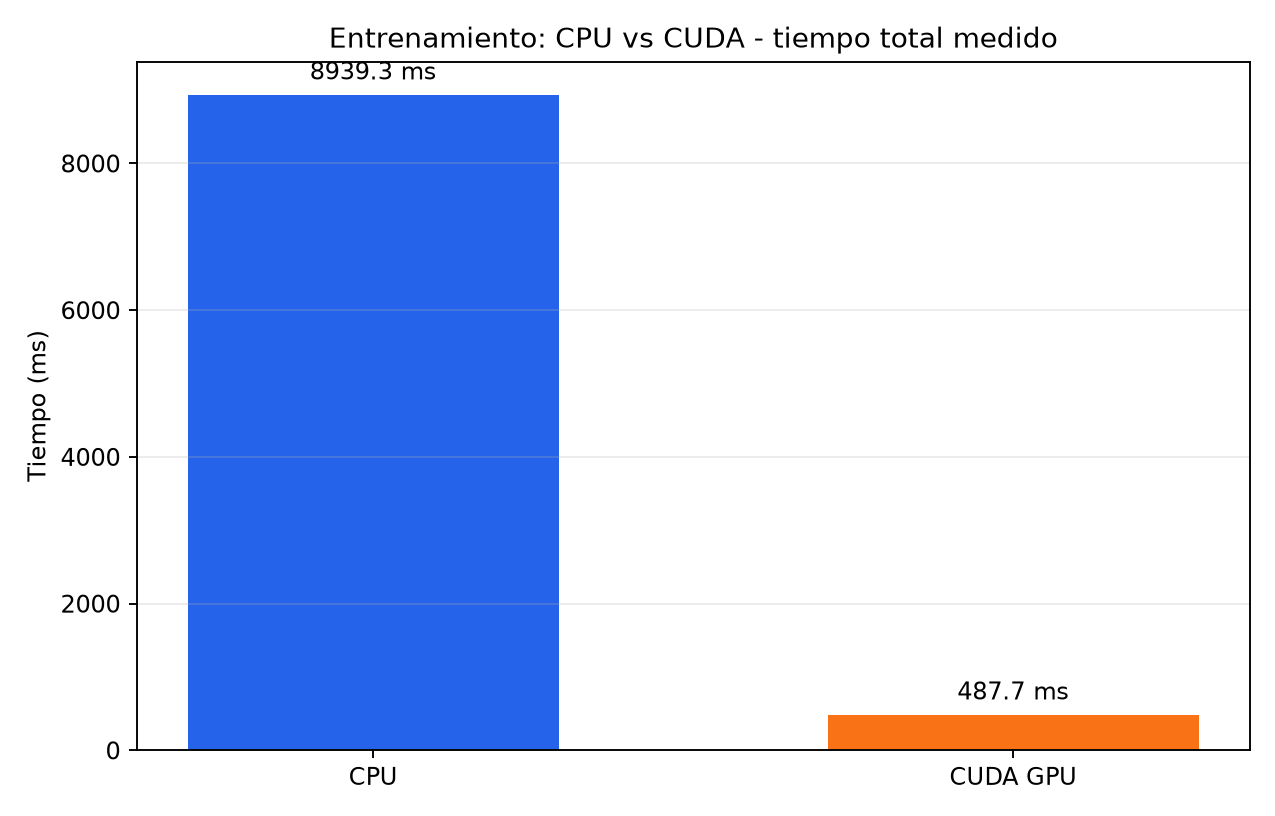

In [5]:
for filename in ["openmp_speedup.png", "cuda_speedup.png"]:
    path = METRICS / filename
    if path.exists():
        display(Image(filename=str(path)))
    else:
        print(f"No existe {filename}.")


## Bloque 6: calcular speedup desde los reportes JSON

Este bloque vuelve a calcular el speedup usando los valores guardados. Sirve para verificar que la grafica coincide con los datos numericos.


In [6]:
openmp_json = METRICS / "openmp_benchmark.json"
cuda_json = METRICS / "cuda_training.json"

if openmp_json.exists():
    openmp = json.loads(openmp_json.read_text(encoding="utf-8"))
    print("OpenMP speedup:", openmp["serial_ms"] / openmp["openmp_ms"])
else:
    print("No existe openmp_benchmark.json.")

if cuda_json.exists():
    cuda = json.loads(cuda_json.read_text(encoding="utf-8"))
    print("CUDA speedup:", cuda["cpu"]["time_ms"] / cuda["cuda"]["time_ms"])
else:
    print("No existe cuda_training.json.")


OpenMP speedup: 3.934462548845595
CUDA speedup: 18.329971243537944


## Bloque 7: resumen para el informe

Este bloque genera frases cortas que puedes usar en el reporte o en la sustentacion. Debes ajustar la interpretacion final segun los valores que obtengas despues de tu entrenamiento manual.


In [7]:
print("Resumen sugerido:")
print("1. El modelo final se evalua con el conjunto test.")
print("2. La matriz de confusion muestra en que clase se concentran los errores.")
print("3. OpenMP acelera el preprocesamiento al dividir imagenes entre hilos.")
print("4. CUDA acelera el entrenamiento al ejecutar operaciones del MLP en GPU.")
print("5. El modelo usado por la app es el exportado desde los pesos CUDA.")


Resumen sugerido:
1. El modelo final se evalua con el conjunto test.
2. La matriz de confusion muestra en que clase se concentran los errores.
3. OpenMP acelera el preprocesamiento al dividir imagenes entre hilos.
4. CUDA acelera el entrenamiento al ejecutar operaciones del MLP en GPU.
5. El modelo usado por la app es el exportado desde los pesos CUDA.
